In [9]:
import torch
import torch.nn.functional as F

inputs  = torch.tensor([1.0, 2.0, 3.0])
weights = torch.tensor([0.5, -1.0, 2.0])
bias    = torch.tensor(1.0)

weighted_sum = torch.dot(inputs, weights) + bias   # dot product + bias
output = F.relu(weighted_sum)                        # activation
print("Neuron output:", output)

Neuron output: tensor(5.5000)


In [10]:
weighted_sum = torch.dot(inputs, weights) + torch.tensor(-10.0)   # 4.5 + (-10) = -5.5
print("Before ReLU:", weighted_sum)
print("After ReLU: ", F.relu(weighted_sum))    # predict this!

Before ReLU: tensor(-5.5000)
After ReLU:  tensor(0.)


In [11]:
import torch
import torch.nn as nn

# a simple network: 4 inputs → 8 hidden neurons → 3 outputs
model = nn.Sequential(
    nn.Linear(4, 8),    # layer 1: takes 4 inputs, produces 8 numbers
    nn.ReLU(),          # activation on the hidden layer
    nn.Linear(8, 3)     # layer 2: takes those 8, produces 3 outputs
)

print(model)

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=3, bias=True)
)


In [12]:
# one sample with 4 features (like one iris flower!)
x = torch.tensor([[5.1, 3.5, 1.4, 0.2]])

output = model(x)     # push the data through all the layers
print(output)

tensor([[0.0451, 1.0851, 0.0259]], grad_fn=<AddmmBackward0>)


In [14]:
import torch
import torch.nn as nn

# a tiny network: 1 input → 1 output
model = nn.Linear(1, 1)

# the tools for training
loss_fn = nn.MSELoss()                              # measures "how wrong" (mean squared error)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)   # does the downhill step (SGD = gradient descent)

# our single training example: input 1.0 should produce output 2.0
x = torch.tensor([[1.0]])
y = torch.tensor([[2.0]])

# the training loop
for epoch in range(100):
    prediction = model(x)              # 1. forward pass
    loss = loss_fn(prediction, y)      # 2. compute loss (how wrong)

    optimizer.zero_grad()              # reset gradients from last step
    loss.backward()                    # 3. backward pass (autograd computes gradients!)
    optimizer.step()                   # 4. update weights (step downhill)

    if epoch % 10 == 0:                # print every 10 steps
        print(f"epoch {epoch}: loss = {loss.item():.4f}, prediction = {prediction.item():.4f}")

print(f"For Input 4: {model(torch.tensor([[4.0]]))}")

epoch 0: loss = 2.0143, prediction = 0.5807
epoch 10: loss = 0.8903, prediction = 1.0564
epoch 20: loss = 0.3935, prediction = 1.3727
epoch 30: loss = 0.1739, prediction = 1.5829
epoch 40: loss = 0.0769, prediction = 1.7227
epoch 50: loss = 0.0340, prediction = 1.8157
epoch 60: loss = 0.0150, prediction = 1.8774
epoch 70: loss = 0.0066, prediction = 1.9185
epoch 80: loss = 0.0029, prediction = 1.9458
epoch 90: loss = 0.0013, prediction = 1.9640
For Input 4: tensor([[6.2591]], grad_fn=<AddmmBackward0>)


In [15]:
import torch
import torch.nn as nn

model = nn.Linear(1, 1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# MULTIPLE examples — all following the "double it" rule
x = torch.tensor([[1.0], [2.0], [3.0], [5.0], [7.0]])
y = torch.tensor([[2.0], [4.0], [6.0], [10.0], [14.0]])

for epoch in range(500):
    prediction = model(x)
    loss = loss_fn(prediction, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# now test on an input it never saw
print(f"Input 4.0 → {model(torch.tensor([[4.0]])).item():.4f}")   # should be ≈ 8.0 now!

Input 4.0 → 7.9929


In [16]:
import torch
import torch.nn as nn

# a DEEPER network for the same simple "doubling" task
model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

x = torch.tensor([[1.0], [2.0], [3.0], [5.0], [7.0]])
y = torch.tensor([[2.0], [4.0], [6.0], [10.0], [14.0]])

for epoch in range(500):
    prediction = model(x)
    loss = loss_fn(prediction, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"Final loss: {loss.item():.4f}")
print(f"Input 4.0 → {model(torch.tensor([[4.0]])).item():.4f}")   # compare to your simple version's 8.0

Final loss: 1.0256
Input 4.0 → 8.8067


In [2]:
import torch
print(torch.cuda.is_available())    # True = GPU is on and ready

True


Training images: 60000
Test images: 10000
Image shape: torch.Size([1, 28, 28])
Label: 5


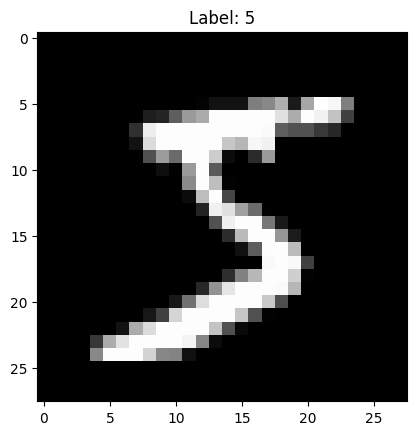

In [3]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# download MNIST (this happens automatically the first time)
transform = transforms.ToTensor()
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(f"Training images: {len(train_data)}")
print(f"Test images: {len(test_data)}")

# look at the first image
image, label = train_data[0]
print(f"Image shape: {image.shape}")   # predict: what shape? (1 channel, 28x28)
print(f"Label: {label}")

# display it
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.show()

In [4]:
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),            # turn the 28x28 image into a flat row of 784 numbers
    nn.Linear(784, 128),     # hidden layer: 784 inputs → 128 neurons
    nn.ReLU(),               # activation (the non-linear kink)
    nn.Linear(128, 64),      # another hidden layer: 128 → 64 neurons
    nn.ReLU(),               # activation
    nn.Linear(64, 10)        # output layer: 64 → 10 (one per digit 0–9)
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# use the GPU if it's on
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)          # move the model onto the GPU
print(f"Training on: {device}")

# feed data in batches of 64 images at a time
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

loss_fn = nn.CrossEntropyLoss()                          # loss for classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)   # the optimizer

# train for 3 passes over the whole dataset
for epoch in range(3):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)   # data to GPU

        predictions = model(images)            # 1. forward pass
        loss = loss_fn(predictions, labels)    # 2. compute loss

        optimizer.zero_grad()                  # reset gradients
        loss.backward()                        # 3. backward pass
        optimizer.step()                       # 4. update weights

    print(f"epoch {epoch+1}: loss = {loss.item():.4f}")

Training on: cuda
epoch 1: loss = 0.1469
epoch 2: loss = 0.1259
epoch 3: loss = 0.0731


In [6]:
from torch.utils.data import DataLoader

# load the 10,000 test images (never seen during training)
test_loader = DataLoader(test_data, batch_size=64)

correct = 0
total = 0

model.eval()                      # put model in evaluation mode
with torch.no_grad():             # don't track gradients — we're not training
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)                      # get the 10 scores per image
        predicted = torch.argmax(outputs, dim=1)     # pick the highest as the guess
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 97.34%


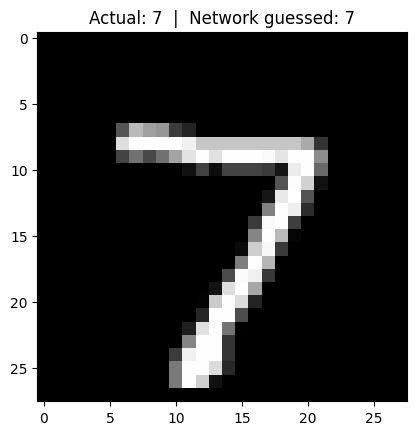

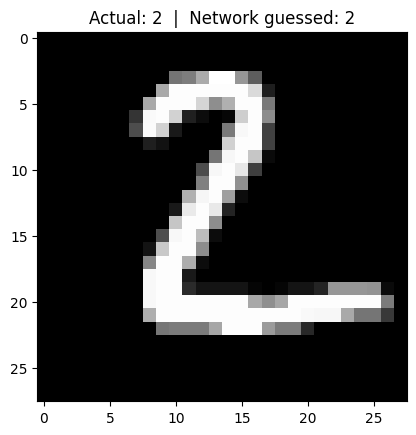

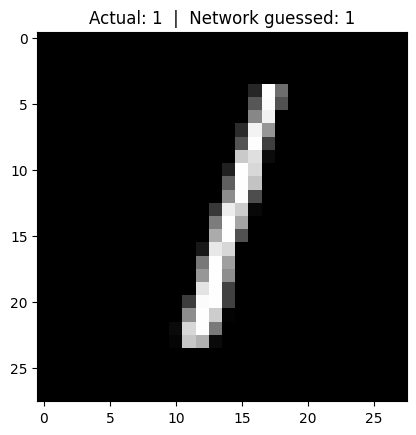

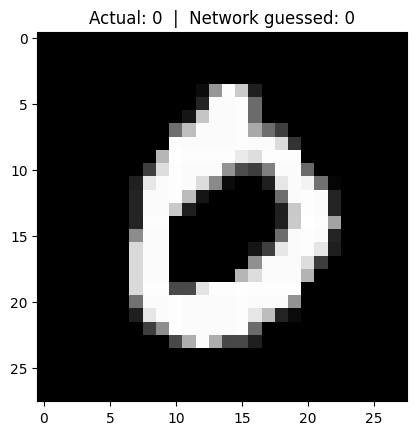

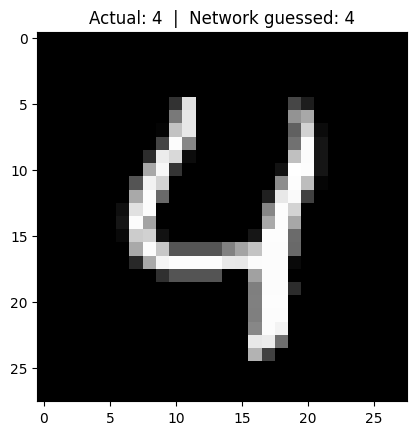

In [7]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    # grab a few test images and predict them
    for i in range(5):
        image, label = test_data[i]
        output = model(image.unsqueeze(0).to(device))
        guess = torch.argmax(output, dim=1).item()

        plt.imshow(image.squeeze(), cmap="gray")
        plt.title(f"Actual: {label}  |  Network guessed: {guess}")
        plt.show()